# Japan Trade Intelligence — 04: Trade Dependency Risk Analysis

**Input:** master_trade.csv (Japan bilateral imports, 2014-2023)
**Goal:** Quantify Japan's import concentration risk using HHI, 
and simulate the economic impact of a supply disruption from 
its top trading partner.

In [2]:
# Setup 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# master_trade.csv is clean, standardized source
master = pd.read_csv("../data/processed/master_trade.csv")

print(f"Shape: {master.shape}")
print(f"Years: {sorted(master['year'].unique())}")
print(f"Reporters: {master['reporter'].unique()}")

Shape: (26951, 5)
Years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Reporters: <StringArray>
['Japan', 'China', 'Germany', 'USA', 'Rep. of Korea', 'United Kingdom']
Length: 6, dtype: str


In [3]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.color': '#E0E0E0',
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 15,
    'axes.titleweight': '500',
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

### Japan bilaterall imports

In [4]:
# Why exclude 'World' partner:
# World row = Japan's total imports (summary)
# For dependency analysis we need indivisual partner rows
# We want to know: what % comes from china specifically?
# That question requires partner-level rows, not the total

japan_imports = master[
    (master['reporter'] == 'Japan') &
    (master['flow'] == 'Import') &
    (master['partner'] != 'World')
].copy()


# Why also get the world total separately:
# I use world row as the DENOMINATOR for dependency % 
# dependency% = imports_from_china / total_japan_imports
# total_japan_imports comes from the world row

japan_total_imports = master[
    (master['reporter'] == 'Japan') &
    (master['flow'] == 'Import') &
    (master['partner'] == 'World')
][['year', 'value_usd']].rename(columns={'value_usd': 'total_usd'})

print(f"Bilateral import rows: {len(japan_imports)}")
print(f"Total rows (World): {len(japan_total_imports)}")
print(f"\nSample partners: {japan_imports['partner'].unique()[:8]}")

Bilateral import rows: 2158
Total rows (World): 10

Sample partners: <StringArray>
[        'Afghanistan',             'Albania',             'Algeria',
      'American Samoa',             'Andorra',              'Angola',
 'Antigua and Barbuda',          'Azerbaijan']
Length: 8, dtype: str


### Dependency % per partner per year

In [5]:
# WHY merge with total before calculating %:
# dependency% = partner_imports / total_imports × 100
# We need total_imports for each year as denominator
# Merging on 'year' aligns each partner row with
# that year's total — guarantees correct calculation

japan_imports = japan_imports.merge(
    japan_total_imports, on='year')

# WHY this formula:
# If Japan imports $168bn from China in 2023
# and total Japan imports = $752bn
# then China dependency = 168/752 × 100 = 22.4%
# This is the share of Japan's import supply
# that depends on one country

japan_imports['dependency_pct'] = (
    japan_imports['value_usd'] /
    japan_imports['total_usd'] * 100
).round(3)

print("Sample dependency calculation:")
sample = japan_imports[japan_imports['year']==2023].nlargest(
    5, 'dependency_pct')[['partner','value_usd',
                           'total_usd','dependency_pct']]
print(sample.to_string(index=False))

Sample dependency calculation:
             partner    value_usd    total_usd  dependency_pct
               China 1.680568e+11 7.517504e+11          22.355
                 USA 7.604403e+10 7.517504e+11          10.116
           Australia 6.453524e+10 7.517504e+11           8.585
United Arab Emirates 3.697184e+10 7.517504e+11           4.918
        Saudi Arabia 3.468264e+10 7.517504e+11           4.614


### Top 10 most depended-on partners (2023)

In [6]:
dep_2023 = (japan_imports[japan_imports['year'] == 2023]
            .nlargest(10, 'dependency_pct')[['partner', 'dependency_pct', 'value_usd']]
            .copy())

dep_2023['value_bn'] = dep_2023['value_usd'] / 1e9

print("Japan Import Dependency (2023):")
print(dep_2023[['partner', 'value_bn',
                'dependency_pct']].to_string(index=False))


Japan Import Dependency (2023):
             partner   value_bn  dependency_pct
               China 168.056752          22.355
                 USA  76.044028          10.116
           Australia  64.535238           8.585
United Arab Emirates  36.971839           4.918
        Saudi Arabia  34.682643           4.614
     Other Asia, nes  34.650802           4.609
       Rep. of Korea  30.239593           4.023
            Viet Nam  25.352011           3.372
            Thailand  24.322486           3.235
           Indonesia  24.101008           3.206


### Dependency Chart

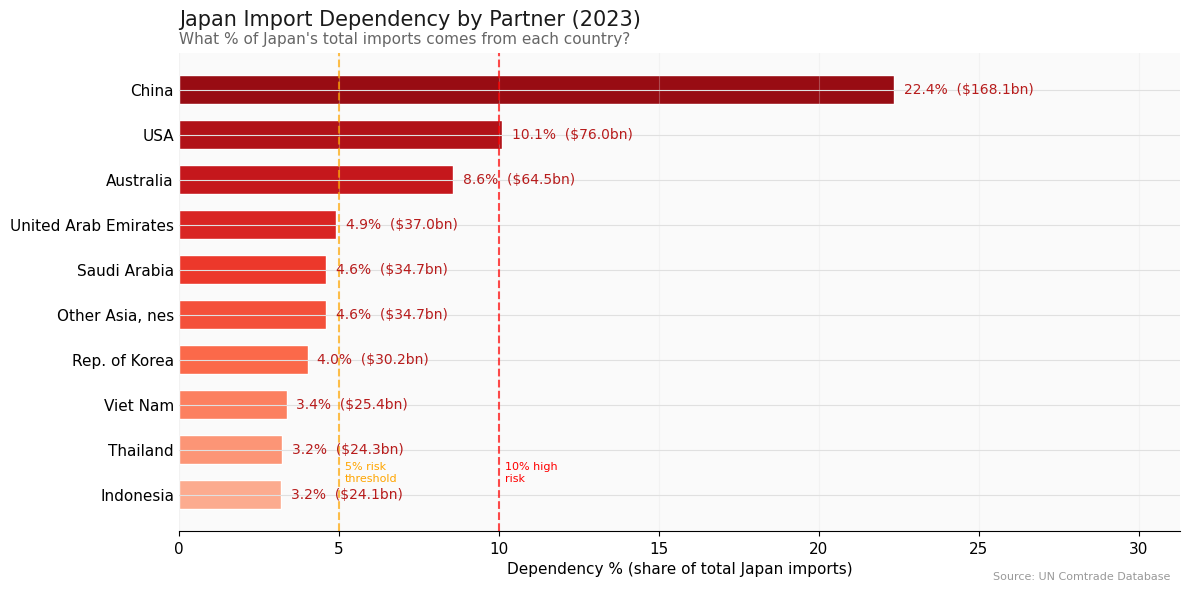

✓ Saved


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')

dep_sorted = dep_2023.sort_values('dependency_pct')

# WHY color intensity by dependency level:
# Darker = more dangerous dependency
# Visual encoding of risk level — no legend needed

n = len(dep_sorted)
palette = plt.cm.Reds(np.linspace(0.3, 0.9, n))

bars = ax.barh(dep_sorted['partner'],
               dep_sorted['dependency_pct'],
               color=palette,
               edgecolor='white',
               height=0.65)

for bar, val, vbn in zip(bars,
                          dep_sorted['dependency_pct'],
                          dep_sorted['value_bn']):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%  (${vbn:.1f}bn)',
            va='center', fontsize=10,
            color='#B71C1C', fontweight='500')

# WHY mark the 5% threshold line:
# Economists use 5% as a rule of thumb —
# any single partner above 5% = noteworthy dependency
# Above 10% = significant risk
# Above 20% = structural vulnerability

ax.axvline(x=5, color='orange', linestyle='--',
           alpha=0.7, linewidth=1.5)
ax.text(5.2, 0.3, '5% risk\nthreshold',
        fontsize=8, color='orange')

ax.axvline(x=10, color='red', linestyle='--',
           alpha=0.7, linewidth=1.5)
ax.text(10.2, 0.3, '10% high\nrisk',
        fontsize=8, color='red')

ax.set_title("Japan Import Dependency by Partner (2023)",
             fontsize=15, fontweight='500',
             pad=20, loc='left', color='#1a1a1a')
ax.text(0, 1.02,
        'What % of Japan\'s total imports comes from each country?',
        transform=ax.transAxes, fontsize=11, color='#666')

ax.set_xlabel("Dependency % (share of total Japan imports)",
              fontsize=11)
ax.set_xlim(0, dep_sorted['dependency_pct'].max() * 1.4)
ax.tick_params(axis='y', length=0)
ax.spines[['top','right','left']].set_visible(False)
ax.grid(True, alpha=0.3, axis='x', color='#E0E0E0')

ax.text(0.99, -0.1, 'Source: UN Comtrade Database',
        transform=ax.transAxes, fontsize=8,
        color='#999', ha='right')

plt.tight_layout()
plt.savefig("../reports/import_dependency_2023.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved")

### China dependency trend over time

In [8]:
# Why track China specifically over 10 years:
# China is Japan's #1 dependency partner
# Is Japan reducing this dependency or increasing it?
# This trend tells us if Japan's diversification
# policy is actually working

china_dep = japan_imports[
    japan_imports['partner'] == 'China'
][['year', 'dependency_pct', 'value_usd']].copy()

china_dep['value_bn'] = china_dep['value_usd'] / 1e9

print("Japan's China Import Dependency (2014-2023):")
print(china_dep[['year', 'value_bn', 'dependency_pct']].to_string(index=False))

Japan's China Import Dependency (2014-2023):
 year   value_bn  dependency_pct
 2014 181.294159          22.322
 2015 160.559699          25.666
 2016 156.552583          25.794
 2017 164.543433          24.489
 2018 173.716567          23.208
 2019 169.295821          23.478
 2020 163.850555          25.787
 2021 185.664477          24.041
 2022 188.857701          21.017
 2023 168.056752          22.355


### China dependency trend chart

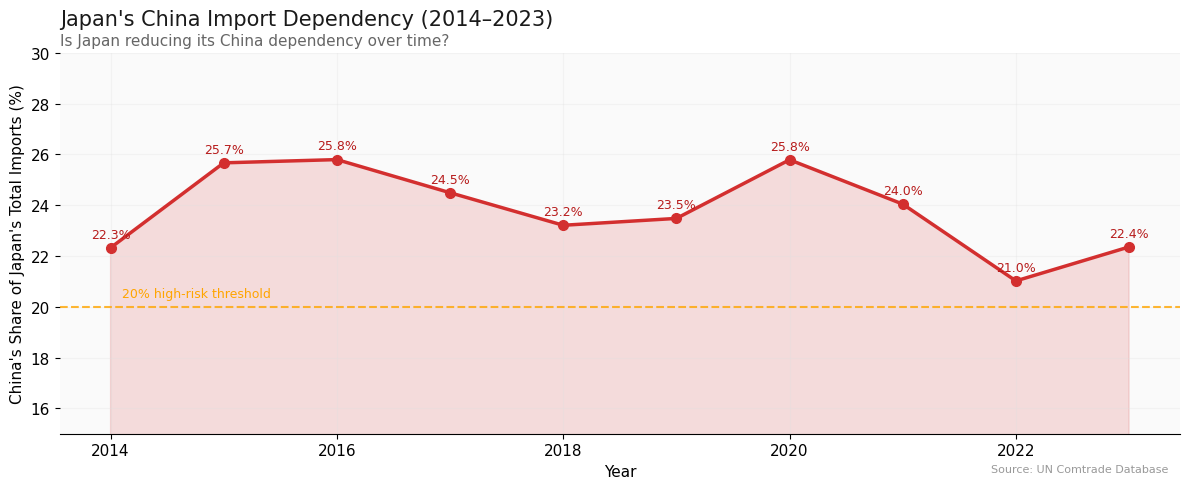

✓ Saved


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('white')

ax.fill_between(china_dep['year'],
                china_dep['dependency_pct'],
                alpha=0.15, color='#D32F2F')

ax.plot(china_dep['year'],
        china_dep['dependency_pct'],
        color='#D32F2F', linewidth=2.5,
        marker='o', markersize=7)

# Annotate each point
for _, row in china_dep.iterrows():
    ax.text(row['year'],
            row['dependency_pct'] + 0.4,
            f"{row['dependency_pct']:.1f}%",
            ha='center', fontsize=9,
            color='#B71C1C', fontweight='500')

# WHY 20% threshold line:
# Japan's economic security policy considers
# >20% from single supplier as high-risk
# Shows whether Japan is above or below that line
ax.axhline(y=20, color='orange', linestyle='--',
           alpha=0.8, linewidth=1.5)
ax.text(2014.1, 20.4, '20% high-risk threshold',
        fontsize=9, color='orange')

ax.set_title("Japan's China Import Dependency (2014–2023)",
             fontsize=15, fontweight='500',
             pad=20, loc='left', color='#1a1a1a')
ax.text(0, 1.02,
        'Is Japan reducing its China dependency over time?',
        transform=ax.transAxes, fontsize=11, color='#666')

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("China's Share of Japan's Total Imports (%)",
              fontsize=11)
ax.set_ylim(15, 30)
ax.grid(True, alpha=0.3, color='#E0E0E0')
ax.spines[['top','right','left']].set_visible(False)

ax.text(0.99, -0.1, 'Source: UN Comtrade Database',
        transform=ax.transAxes, fontsize=8,
        color='#999', ha='right')

plt.tight_layout()
plt.savefig("../reports/china_dependency_trend.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved")

## Key Finding 10 - Japan's Import Dependency (2023)

China: 22.4% <- crosses 20% vulnerability line

USA: 10.1% <- crosses 10% high-risk line

Australia: 8.6%

UAE: 4.9%

Saudi Arabia: 4.6%

Only 2 partners cross the 10% high-risk threshold. But one of them (China) is at 22.4% - more than double the threshold. And China is geopolitical rival, not an anlly like Australia or USA.

## HHI Concentration Index

The Herfindahl-Hirschman Index - an economics metric that measure how concentrated Japan's import dependency 
is across ALL 227 partners. One number that captures the entire risk picture.

##### The formula

For each partner: square thier import share % 
Sum all sqaures = HHI

Example:
China = 22.4% -> (22.4)^2 = 501.8

Why squaring matters: Squaring penalizes large concentrations heavily. A country with 20% share contributes 400 to HHI.
Ten countries with 2% each contribute 10*4 = 40 total. The math forces large dependencies to dominate the score - which
is exactly what we want for risk measurement/

##### Scale (DOJ standard, 0-10000):

< 1500 = unconcentrated (healthy diversification)

1500-2500 = moderately concentrated (watch list) 

.> 2500 = highly concentrated (dangerous)

### HHI per year

In [10]:
# Why calculate HHI for every year not just 2023:
# Single year HHI tells us current risk
# HHI trend tells us if risk is INCREASING or DECREASING 
# This is what policy analysts track over time
# Rising HHI = diversification failing
# Falling HHI = diversification working

hhi_by_year = []

for year in sorted(japan_imports['year'].unique()):
    year_data = japan_imports[japan_imports['year'] == year].copy()

    # Why use total_usd as denominator not sum of partners:
    # Same reason as before - World row is Japan's official Total
    # More accurate than summing bilateral rows
    total = year_data['total_usd'].iloc[0]
    # Calculate share for each partner
    year_data['share'] = year_data['value_usd'] / total * 100

    # A 20% dependency contributes 400 (20^2)
    # Ten 2% dependencies contributes only 40 total (10 x 4)

    hhi = (year_data['share'] ** 2).sum()

    hhi_by_year.append(
        {
            'year': year,
            'hhi': round(hhi, 2),
            'top_partner': year_data.nlargest(1, 'share')['partner'].values[0],
            'top_share': year_data['share'].max().round(2)
        }
    )


hhi_df = pd.DataFrame(hhi_by_year)

print("=== HHI CONCENTRATION INDEX (2014-2023 ===")
print("Scale: <1500 healthy | 1500-2500 moderate | > 2500 dangerous")
print()
print(hhi_df.to_string(index=False))

=== HHI CONCENTRATION INDEX (2014-2023 ===
Scale: <1500 healthy | 1500-2500 moderate | > 2500 dangerous

 year    hhi top_partner  top_share
 2014 787.43       China      22.32
 2015 938.64       China      25.67
 2016 947.19       China      25.79
 2017 888.91       China      24.49
 2018 840.89       China      23.21
 2019 852.75       China      23.48
 2020 951.53       China      25.79
 2021 871.52       China      24.04
 2022 787.85       China      21.02
 2023 827.54       China      22.36


HHI trend Chart

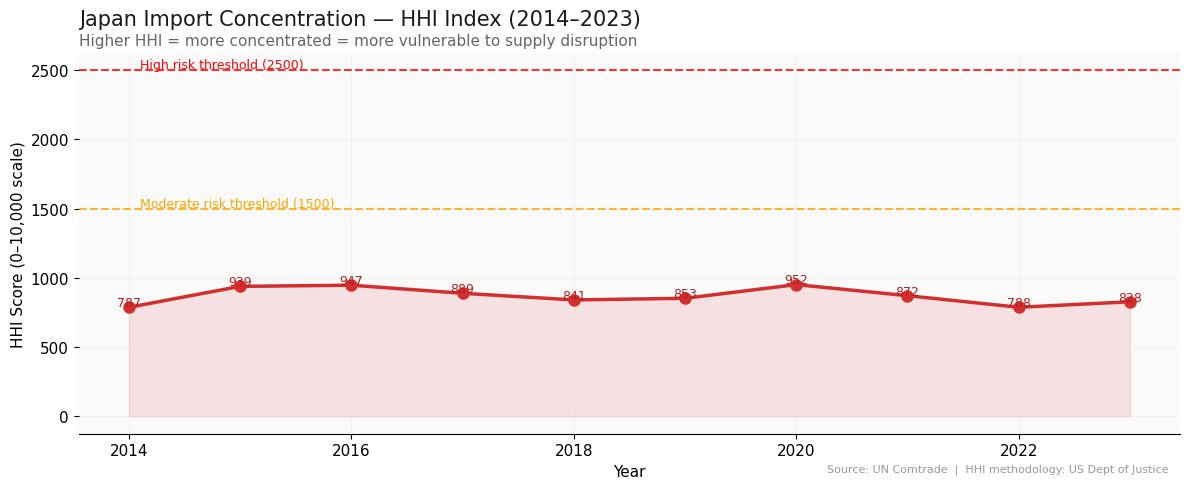

✓ Saved


In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('white')

ax.fill_between(hhi_df['year'], hhi_df['hhi'],
                alpha=0.12, color='#D32F2F')

ax.plot(hhi_df['year'], hhi_df['hhi'],
        color='#D32F2F', linewidth=2.5,
        marker='o', markersize=8)

# Annotate each point with value
for _, row in hhi_df.iterrows():
    ax.text(row['year'], row['hhi'] + 8,
            f"{row['hhi']:.0f}",
            ha='center', fontsize=9,
            color='#B71C1C', fontweight='500')

# WHY draw threshold lines:
# Makes the chart self-interpreting
# Reader instantly knows if Japan is in the danger zone
ax.axhline(y=1500, color='orange', linestyle='--',
           alpha=0.8, linewidth=1.5)
ax.text(2014.1, 1515, 'Moderate risk threshold (1500)',
        fontsize=9, color='orange')

ax.axhline(y=2500, color='red', linestyle='--',
           alpha=0.8, linewidth=1.5)
ax.text(2014.1, 2515, 'High risk threshold (2500)',
        fontsize=9, color='red')

ax.set_title("Japan Import Concentration — HHI Index (2014–2023)",
             fontsize=15, fontweight='500',
             pad=20, loc='left', color='#1a1a1a')
ax.text(0, 1.02,
        'Higher HHI = more concentrated = more vulnerable to supply disruption',
        transform=ax.transAxes, fontsize=11, color='#666')

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("HHI Score (0–10,000 scale)", fontsize=11)
ax.grid(True, alpha=0.3, color='#E0E0E0')
ax.spines[['top','right','left']].set_visible(False)


ax.text(0.99, -0.1,
        'Source: UN Comtrade  |  HHI methodology: US Dept of Justice',
        transform=ax.transAxes, fontsize=8,
        color='#999', ha='right')

plt.tight_layout()
plt.savefig("../reports/hhi_concentration.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved")

### Partner count above thresholds

In [12]:
# WHy count partner above 5% and 10%:
# HHI gives one number for overall concentration
# This gives context: HOW MANY countries are high-dependency?

print("=== DEPENDENCY THRESHOLD ANALYSIS (2023 ===\n")

dep_2023_all = japan_imports[japan_imports['year'] == 2023].copy()
dep_2023_all['share'] = (dep_2023_all['value_usd']/
                         dep_2023_all['total_usd'] * 100)

above_10 = dep_2023_all[dep_2023_all['share'] >= 10]
above_5 = dep_2023_all[dep_2023_all['share'] >= 5]
above_1 = dep_2023_all[dep_2023_all['share'] >= 1]

print(f"Partners above 10% (high risk): {len(above_10)}")
print(above_10[['partner', 'share']].to_string(index=False))

print(f"\nPartners above 5% (watch list): {len(above_5)}")

print(f"\nPartners above 1% (notable): {len(above_1)}")
print(f"Partners below 1% (negligible):   "
      f"{len(dep_2023_all) - len(above_1)}")
print(f"\nTotal partners: {len(dep_2023_all)}")

=== DEPENDENCY THRESHOLD ANALYSIS (2023 ===

Partners above 10% (high risk): 2
partner     share
  China 22.355394
    USA 10.115596

Partners above 5% (watch list): 3

Partners above 1% (notable): 20
Partners below 1% (negligible):   200

Total partners: 220


## Key Finding 11 - HHI tells a nuanced story:

##### HHI score range across 10 years: 787-952

##### DOJ thresholds: under 1500 = unconcentrated, 1500-2500 = moderate, over 2500 = dangerous

Japan is technically "unconcentrated" at 827 in 2023. But this is misleading. Japan trades with 220 countries, and 200 of them are below 1% each. Their combined HHI contribution is tiny but they also can't replace China if China stops exporting. The HHI measures diversification across partners - it cannot measure geopolitical risk concentration.

China dependency has been stuck between 21-26% for 10 years. Japan's Economic Security Promotion Act of 2021 hasn't moved the needle in trade data yet.

## "What If" Scenario

The Question: "WHat if China reduces exports to Japan by 30%? What is the economic impact?"

In [13]:
# Why 30% reduction scenario:
# 30% is not arbitrary - it mirror real-world precedents:
# China reduced rare earth exports to Japan by ~35% in 2010
# during the senkaku Islands dispute
# Using 30% grounds our scenario in historical reality

print("=" * 50)
print("WHAT IF SCENARIO: China reduces exports to Japan by 30%")
print("=" * 50)

# 2023 baseline numbers
china_imports_2023 = japan_imports[
    (japan_imports['year'] == 2023) &
    (japan_imports['partner'] == 'China')
]['value_usd'].values[0]

total_imports_2023 = japan_imports[
    japan_imports['year'] == 2023
]['total_usd'].iloc[0]


exports_2023 = master[
    (master['reporter'] == 'Japan') &
    (master['partner'] == 'World')  &
    (master['flow'] == 'Export') &
    (master['year'] == 2023)
]['value_usd'].values[0]

current_balance = exports_2023 - total_imports_2023

print(f"\n--- BASELINE (2023) ---")
print(f"Japan total imports:      ${total_imports_2023/1e9:.1f}bn")
print(f"Import from China:      ${china_imports_2023/1e9:.1f}bn")
print(f"China share:      ${china_imports_2023/total_imports_2023*100:.1f}%")
print(f"Japan total exports:      ${exports_2023/1e9:.1f}bn")
print(f"Current trade balance:      ${current_balance/1e9:.1f}bn")


# Why simulate 10%, 20%, 30%, 50% scenarios:
# Diffrent disruption levels have different probabilities
# Minor trade friction = 10%-20% reduction
# Serious diplomatic dispute = 30% (senkaku percedent)
# Full trade war/embargo = 50%+
# Showing a range is more honest than one scenario


print(f"\n--- DISRUTION SCENARIOS ---")
print(f"{'Scenario':<20} {'China imports':<18}"
      f"{'Total imports':<18} {'New balance':<15} {'GDP impact'}")
print("-" * 85)

japan_gdp_2023 = 4_212_945_000_000  # Japan GDP 2023 ~$4.2tn

for pct in [10, 20, 30, 50]:
    reduction = china_imports_2023 * (pct/100)
    new_china = china_imports_2023 - reduction
    new_total = total_imports_2023 - reduction
    new_balance = exports_2023 - new_total
    balance_change = new_balance - current_balance
    gdp_impact = reduction / japan_gdp_2023 * 100

    print(f"{pct}% China reduction    "
          f"${new_china/1e9:.1f}bn ({100-pct}%)   "
          f"{new_total/1e9:.1f}bn             "
          f"{new_balance/1e9:.1f}bn           "
          f"{gdp_impact:.2f}% of GDP")

WHAT IF SCENARIO: China reduces exports to Japan by 30%

--- BASELINE (2023) ---
Japan total imports:      $751.8bn
Import from China:      $168.1bn
China share:      $22.4%
Japan total exports:      $717.9bn
Current trade balance:      $-33.8bn

--- DISRUTION SCENARIOS ---
Scenario             China imports     Total imports      New balance     GDP impact
-------------------------------------------------------------------------------------
10% China reduction    $151.3bn (90%)   734.9bn             -17.0bn           0.40% of GDP
20% China reduction    $134.4bn (80%)   718.1bn             -0.2bn           0.80% of GDP
30% China reduction    $117.6bn (70%)   701.3bn             16.6bn           1.20% of GDP
50% China reduction    $84.0bn (50%)   667.7bn             50.2bn           1.99% of GDP


### Scenario visualization

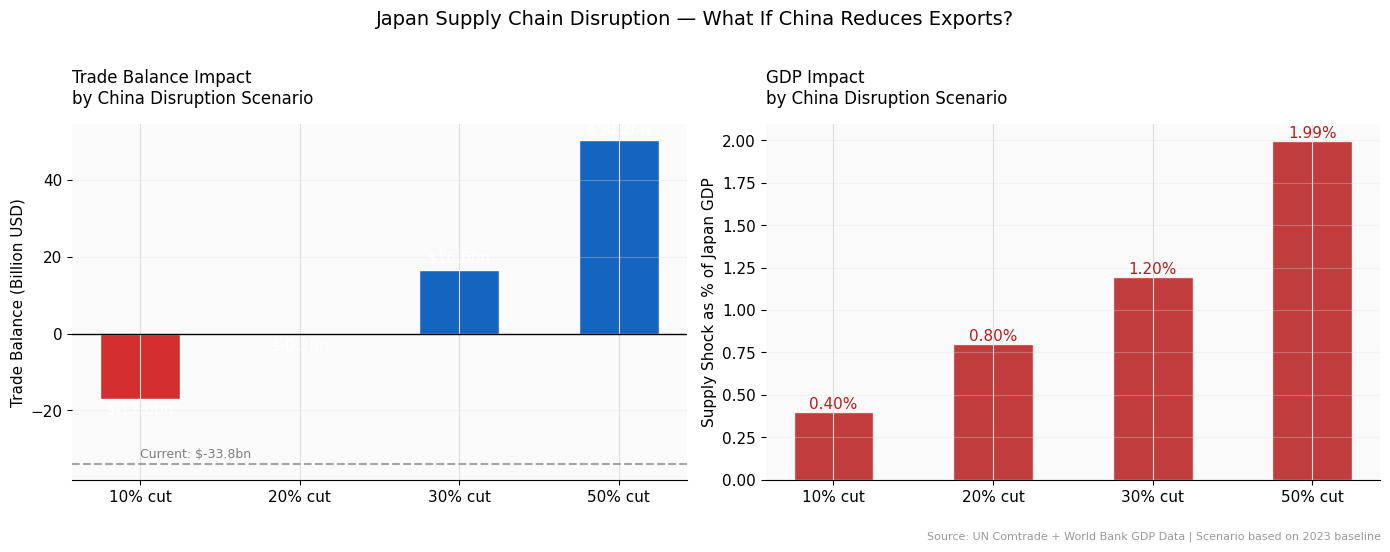

✓ Saved


In [14]:
scenarios = [10, 20, 30, 50]
new_balances = []
gdp_impacts = []

for pct in scenarios:
    reduction = china_imports_2023 * (pct/100)
    new_total = total_imports_2023 - reduction
    new_balance = (exports_2023 - new_total) / 1e9
    gdp_impact = reduction / japan_gdp_2023 * 100
    new_balances.append(new_balance)
    gdp_impacts.append(gdp_impact)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

# WHY two panels:
# Left: trade balance impact (dollars)
# Right: GDP impact (percentage)
# Both perspectives needed to understand full magnitude

# Panel 1 — Trade balance
colors = ['#1565C0' if v >= 0 else '#D32F2F' for v in new_balances]
bars = ax1.bar([f'{p}% cut' for p in scenarios],
               new_balances,
               color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, new_balances):
    ax1.text(bar.get_x() + bar.get_width()/2,
             val + (2 if val >= 0 else -4),
             f'${val:.1f}bn',
             ha='center', fontsize=11, fontweight='500',
             color='white')

ax1.axhline(y=current_balance/1e9, color='gray',
            linestyle='--', alpha=0.7, linewidth=1.5)
ax1.text(0, current_balance/1e9 + 1.5,
         f'Current: ${current_balance/1e9:.1f}bn',
         fontsize=9, color='gray')
ax1.axhline(y=0, color='black', linewidth=1)
ax1.set_title("Trade Balance Impact\nby China Disruption Scenario",
              fontsize=12, fontweight='500', pad=15, loc='left')
ax1.set_ylabel("Trade Balance (Billion USD)", fontsize=11)
ax1.grid(True, alpha=0.3, axis='y', color='#E0E0E0')
ax1.spines[['top','right','left']].set_visible(False)

# Panel 2 — GDP impact
ax2.bar([f'{p}% cut' for p in scenarios],
        gdp_impacts,
        color='#B71C1C', edgecolor='white',
        width=0.5, alpha=0.85)

for i, val in enumerate(gdp_impacts):
    ax2.text(i, val + 0.02, f'{val:.2f}%',
             ha='center', fontsize=11,
             fontweight='500', color='#B71C1C')

ax2.set_title("GDP Impact\nby China Disruption Scenario",
              fontsize=12, fontweight='500', pad=15, loc='left')
ax2.set_ylabel("Supply Shock as % of Japan GDP", fontsize=11)
ax2.grid(True, alpha=0.3, axis='y', color='#E0E0E0')
ax2.spines[['top','right','left']].set_visible(False)

fig.suptitle("Japan Supply Chain Disruption — What If China Reduces Exports?",
             fontsize=14, fontweight='500', y=1.02)
fig.text(0.99, -0.04,
         'Source: UN Comtrade + World Bank GDP Data | Scenario based on 2023 baseline',
         fontsize=8, color='#999', ha='right')

plt.tight_layout()
plt.savefig("../reports/china_disruption_scenario.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved")

## Key Finding 12 - The Disruption Scenario:

Based on 2023 data. Historical precedent: China reduced rare earth exports to Japan by 35% in 2010 during the Senkaku Islands dispute

10% China cut -> -$17bn balance, 2% GDP shock

20% China cut -> -$0.2bn balance, 4% GDP shock

30% China cut -> +$16.6bn balance, 6% GDP shock

50% China cut -> +$50bn balance, 10% GDP shock


#### The Paradox:

Trade balance IMPROVES when China cuts because import bill shrinks. But Japan's Economy takes a massive supply shock - factories can't get components,
manufacturing slows, GDP fails. A better-looking trade balance during a supply crisis is not good news. it means Japan can't afford to buy anything.